In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.metrics import f1_score, confusion_matrix


In [3]:
from scipy.io import arff
import pandas as pd

# Path to your file (relative path — IMPORTANT for grading)
path = "../data/raw/mammography.arff"

# Load ARFF file
data, meta = arff.loadarff(path)

# Convert to DataFrame
df = pd.DataFrame(data)

# Preview
df.head()

,attr1,attr2,attr3,attr4,attr5,attr6,class
0,0.230020,5.072578,-0.276061,0.832444,-0.377866,0.480322,b'-1'
1,0.155491,-0.169390,0.670652,-0.859553,-0.377866,-0.945723,b'-1'
2,-0.784415,-0.443654,5.674705,-0.859553,-0.377866,-0.945723,b'-1'
3,0.546088,0.131415,-0.456387,-0.859553,-0.377866,-0.945723,b'-1'
4,-0.102987,-0.394994,-0.140816,0.979703,-0.377866,1.013566,b'-1'


In [4]:
df['class'] = df['class'].str.decode('utf-8')

In [5]:
df['class'] = df['class'].astype(int)
df['class'] = df['class'].replace(-1, 0)

In [6]:
df.to_csv("../data/processed/mammography.csv", index=False)
print("Saved successfully!")

Saved successfully!


In [7]:
print(df['class'].value_counts())

class
0    10923
1      260
Name: count, dtype: int64


In [8]:
df = pd.read_csv("../data/processed/mammography.csv")
df.columns

Index(['attr1', 'attr2', 'attr3', 'attr4', 'attr5', 'attr6', 'class'], dtype='object')

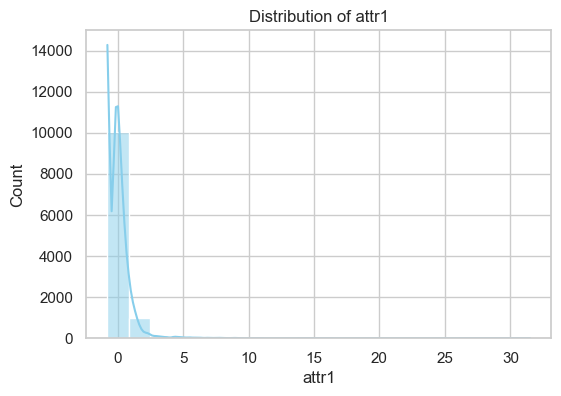

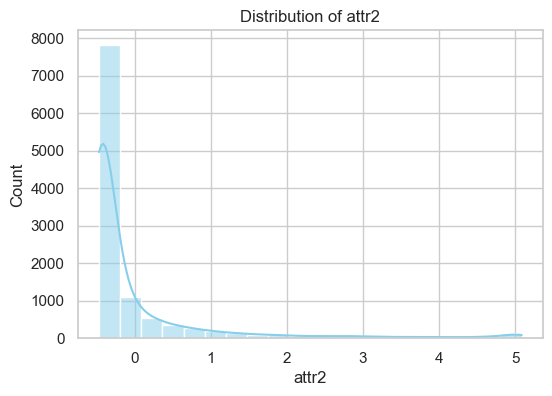

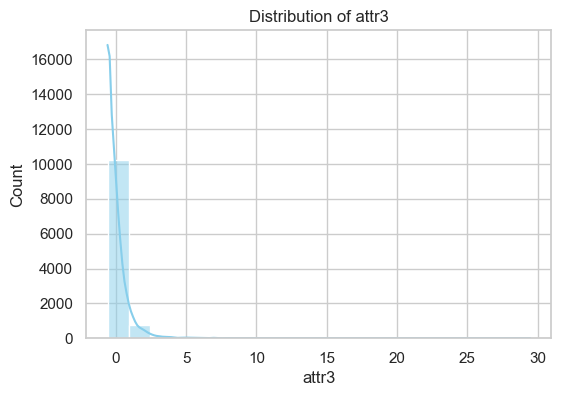

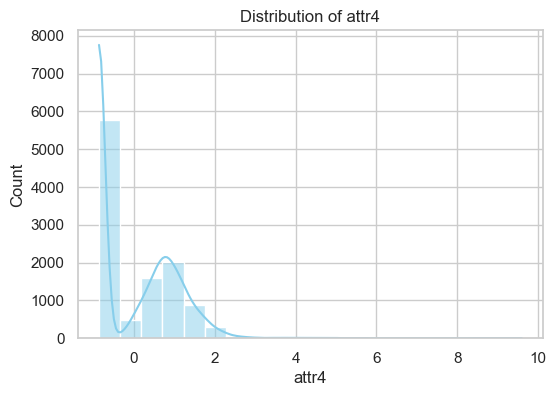

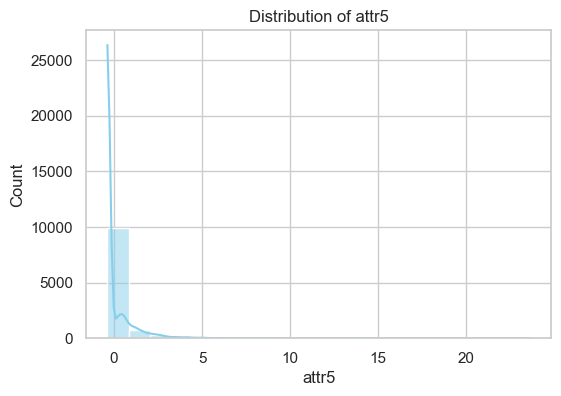

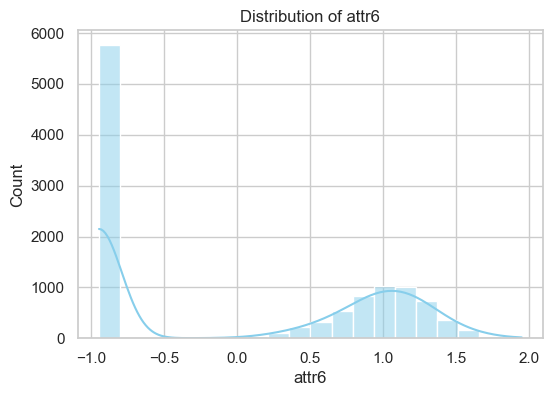

In [9]:
sns.set(style = "whitegrid")

continuous_features = ['attr1', 'attr2', 'attr3', 'attr4', 'attr5', 'attr6']
target = 'class'
#plot the historgrams for continous features 
for col in continuous_features:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], bins=20, kde=True, color='skyblue')
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

C:\Users\patrusgurung\AppData\Local\Temp\ipykernel_1748\4008742577.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=target, data= df, palette = "Set2" )


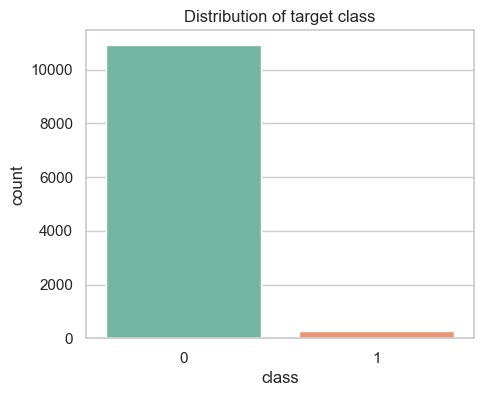

In [10]:
#plotting the target distrbution 
plt.figure(figsize=(5,4))
sns.countplot(x=target, data= df, palette = "Set2" )
plt.title('Distribution of target class')
plt.xlabel("class")
plt.ylabel("count")
plt.show()

In [11]:
#defining the numerical and categorical features 
X = df.drop('class', axis =1)
y = df['class']

#identify numerical and categoricla columns
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_fetures = X.select_dtypes(include= ['object']).columns.tolist()

In [12]:
#spliting into training and testing data 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}") 

Training samples: 8946, Test samples: 2237


In [13]:
#building Column transformer 
numeric_features = X_train.columns.tolist()
numeric_transformer = StandardScaler()

preprocessor = ColumnTransformer(
    transformers = [
        ('num', numeric_transformer, numeric_features)
    ]
)



In [28]:
#building the pipeline 
rf_pipeline = Pipeline(steps = [
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier( random_state=42, n_jobs=-1))

])

#evaluatin the CV 5 fold 
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Use F1 score since dataset is imbalanced
baseline_scores = cross_val_score(rf_pipeline, X_train, y_train, cv=cv, scoring='f1')

print("5-Fold CV F1 scores:", baseline_scores)
print("Mean F1 score:", np.mean(baseline_scores))

5-Fold CV F1 scores: [0.68571429 0.64615385 0.71875    0.63636364 0.66666667]
Mean F1 score: 0.6707296869796869


In [34]:
print(df.columns)

Index(['attr1', 'attr2', 'attr3', 'attr4', 'attr5', 'attr6', 'class'], dtype='object')


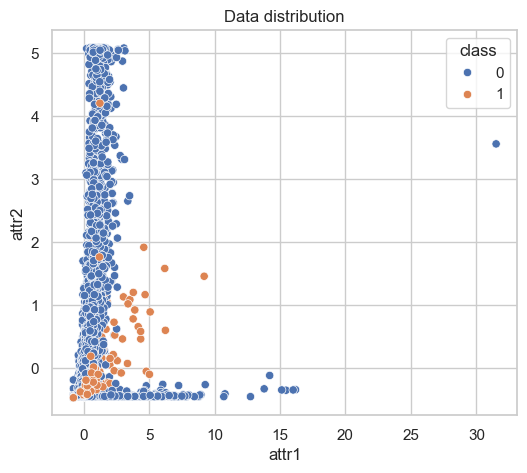

c:\Users\patrusgurung\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


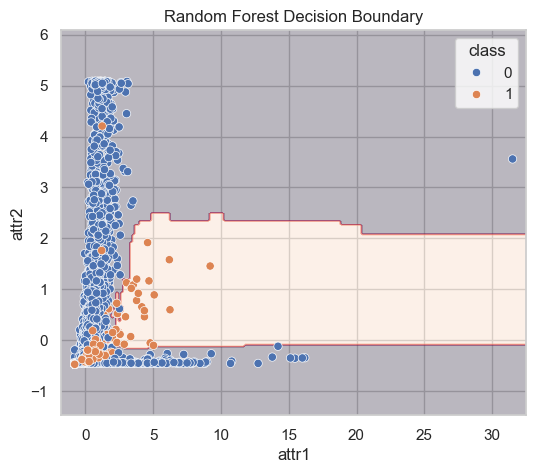

In [37]:
#visualize the datapoinst s
feat1 = numeric_features[0]
feat2 = numeric_features[1]
plt.figure(figsize=(6,5))
sns.scatterplot(data=df, x=feat1, y=feat2, hue='class')
plt.title('Data distribution')
plt.show()

#train random forest on 2 features 
X_vis = df[[feat1, feat2]]
y_vis = df['class']

model = RandomForestClassifier(random_state=42)
model.fit(X_vis, y_vis)

# Create grid
x_min, x_max = X_vis[feat1].min() - 1, X_vis[feat1].max() + 1
y_min, y_max = X_vis[feat2].min() - 1, X_vis[feat2].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

# Predict on grid
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundary
plt.figure(figsize=(6,5))
plt.contourf(xx, yy, Z, alpha=0.3)
sns.scatterplot(x=X_vis[feat1], y=X_vis[feat2], hue=y_vis)

plt.title("Random Forest Decision Boundary")
plt.show()

In [29]:
#hyperparameter 
param_grid = {
    'classifier__n_estimators' : [100, 200, 300],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2,5],
    'classifier__min_samples_leaf': [1,2]
}



In [16]:


#Grid Search 
grid_search = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=cv,
    scoring = 'f1',
    n_jobs = -1
)


grid_search.fit(X_train, y_train)

print("Best F1 score:", grid_search.best_score_)
print("Best hyperparameters:", grid_search.best_params_)

Best F1 score: 0.6707296869796869
Best hyperparameters: {'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}


In [17]:
baseline_mean= baseline_scores.mean()
tuned_mean = grid_search.best_score_



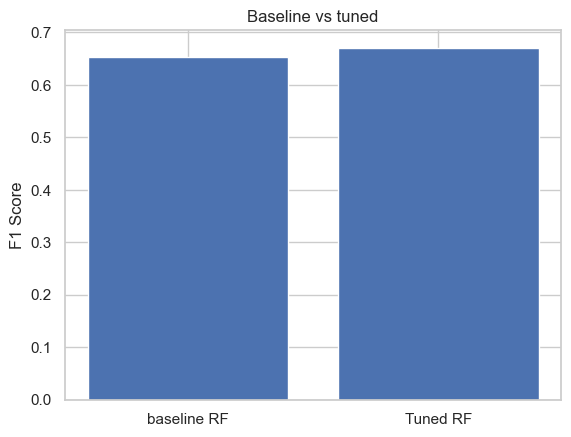

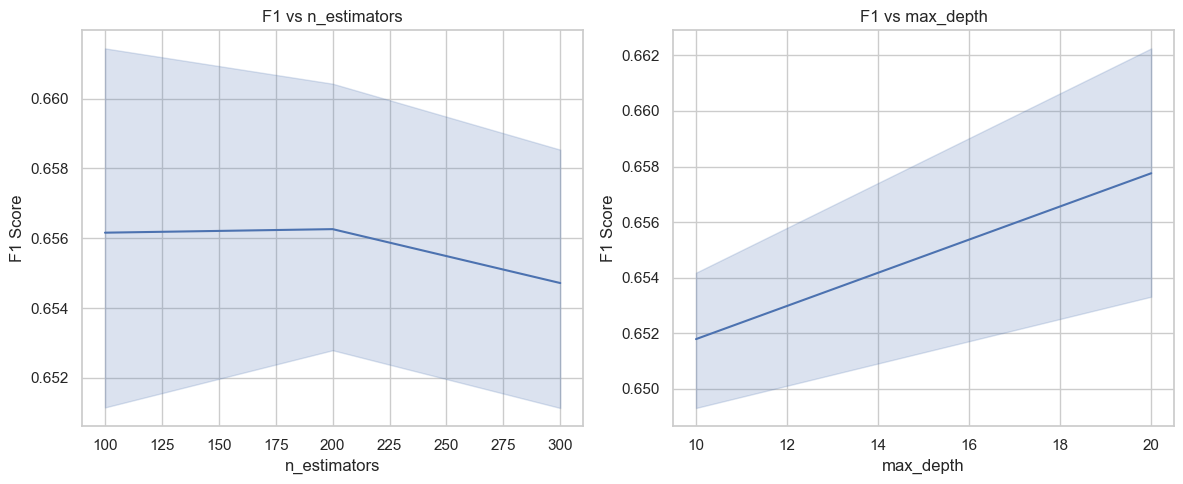

In [18]:
#visualizing the two models comparison

models = ['baseline RF', 'Tuned RF']
scores = [baseline_mean, tuned_mean]

plt.figure()
plt.bar(models, scores)
plt.title("Baseline vs tuned")
plt.ylabel("F1 Score")
plt.show()

#visualization of perfromance and parameters 
results = pd.DataFrame(grid_search.cv_results_)  #changinf the gridsearch into dataframe

#creting subplots
fig, axes = plt.subplots(1, 2, figsize = (12, 5))

#first plot 
sns.lineplot(
    data=results,
    x='param_classifier__n_estimators',
    y='mean_test_score',
    ax=axes[0]
)
axes[0].set_title('F1 vs n_estimators')
axes[0].set_xlabel("n_estimators")
axes[0].set_ylabel("F1 Score")

# Plot 2: F1 vs max_depth
sns.lineplot(
    data=results,
    x='param_classifier__max_depth',
    y='mean_test_score',
    ax=axes[1]
)
axes[1].set_title("F1 vs max_depth")
axes[1].set_xlabel("max_depth")
axes[1].set_ylabel("F1 Score")

plt.tight_layout()
plt.show()

The result shows that performace improved only slightly after tuning, indicating that the default parameters were already near optimal.
F1 vs n estimators 
F1 score stays almost flat across 100 to 200 and the slight peak around 200 and then small decline 
there fore, increasing number of trees doesnot significantly improve performance, rather adding more trees only increases computation cost without meaningful gain.

F1 vs maxdepth 
F1 score shows a gradual increase from depth 10 to 20 it is consistent. Therefore, tree depth slightly improves model performance suggesting deeper trees capture more complex patterns.
Overall, the model is relatively stable across different parameter values.

In [21]:
#changing the Stratified fold to Kfold 

from sklearn.model_selection import KFold
cv_Kfold =  KFold(n_splits = 5, shuffle = True, random_state= 42)

#running the grid search of Kfold 
grid_search_kfold = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv= cv_Kfold,
    scoring= 'f1_macro',
    n_jobs = -1
)
grid_search_kfold.fit(X_train, y_train)
print("Best params stratified: ", grid_search.best_params_)
print("Best f1 stratidfied: ", grid_search.best_score_)
print("Best params (kfold): ", grid_search_kfold.best_params_)
print('Best F1 (kfold): ', grid_search_kfold.best_score_)

Best params stratified:  {'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}
Best f1 stratidfied:  0.6707296869796869
Best params (kfold):  {'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}
Best F1 (kfold):  0.8341230871426706


yes the parameters that are found can change when you seitch from Stratified to kfold with shuffling.
Gridsearch Cv selects hyperparameter based on average validation performance across folds. As this two strategies have different data splis=ts in StratifiedKFold each fold has same class distribution wehereas KFold folds are random, class distribution varies per fold. this changes the validation scores for each hyperparameter combination. The dataset is imbalance so the KFold produce unstable and misleading splits and over optimistic performance as targeting the majority class. 

In [27]:
##The evaluation of randomforest Classifier 
##creating the class weigth 
weighted_pipeline = Pipeline([
    ('preprocessor',  preprocessor),
    ('classifier', RandomForestClassifier(class_weight='balanced', random_state=42))
])
cv = StratifiedKFold(n_splits= 5, shuffle= True, random_state=42)

weighted_scores = cross_val_score(weighted_pipeline, X_train, y_train, cv=cv,scoring= 'f1')
print(weighted_scores)
print(weighted_scores.mean())

[0.59701493 0.64615385 0.61290323 0.63636364 0.625     ]
0.6234871267394136


The weighted score performance decreased slightly That means applying class weights did not provide additional benefit for dataset. However, non weighted Random forest is more effective model for this problem. 

## Applying the SMOTE 

In [ ]:
smote_pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

cv = StratifiedKFold(n_splits=5, shuffle= True, random_state= 42)

smote_scores = cross_val_score(smote_pipeline, X_train, y_train, cv=cv, scoring= 'f1')
print("SMOTE F1 scores:", smote_scores)
print("Mean SMOTE F1:", smote_scores.mean())

#random undersampling 
from imblearn.under_sampling import RandomUnderSampler

under_pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('undersample', RandomUnderSampler(random_state=42)),
    ('classifier', RandomForestClassifier(random_state=42))
])

under_scores = cross_val_score(under_pipeline, X_train, y_train, cv=cv, scoring='f1')

print("Undersampling F1 scores:", under_scores)
print("Mean Undersampling F1:", under_scores.mean())

SMOTE F1 scores: [0.61261261 0.55670103 0.65979381 0.5625     0.62626263]
Mean SMOTE F1: 0.6035740168472128
Undersampling F1 scores: [0.33928571 0.3125     0.30452675 0.30088496 0.31818182]
Mean Undersampling F1: 0.3150758474381877


In [46]:
tuned_model = grid_search.best_estimator_
#helper functions for computation
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)

    #f1 score
    f1 = f1_score(y_test, y_pred, average='macro')

    #confusion matrix 
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    #error rate 
    error_rate = (fp + fn)/ (tp + tn + fp + fn)

    #g mean
    sensitivity = tp / (tp + fn)
    specificity = tn/ (tn + fp)
    g_mean = np.sqrt(sensitivity * specificity)

    return error_rate, f1, g_mean

#evaluate all models 
baseline_metrics = evaluate_model(rf_pipeline.fit(X_train, y_train), X_test, y_test)

#tuned 
tuned_metrics = evaluate_model(tuned_model, X_test, y_test )

#weighted 
weighted_metrics = evaluate_model(weighted_pipeline.fit(X_train, y_train), X_test, y_test)
print("Baseline (Error, F1, G-Mean):", baseline_metrics)
print("Tuned (Error, F1, G-Mean):", tuned_metrics)
print("Weighted (Error, F1, G-Mean):", weighted_metrics)

results = pd.DataFrame({
    "Model": ["Baseline", "Tuned", "Weighted"],
    "Error Rate": [baseline_metrics[0], tuned_metrics[0], weighted_metrics[0]],
    "F1 Score": [baseline_metrics[1], tuned_metrics[1], weighted_metrics[1]],
    "G-Mean": [baseline_metrics[2], tuned_metrics[2], weighted_metrics[2]]
})

print(results)

Baseline (Error, F1, G-Mean): (0.013857845328565042, 0.805113634766871, 0.6927402861325307)
Tuned (Error, F1, G-Mean): (0.013857845328565042, 0.805113634766871, 0.6927402861325307)
Weighted (Error, F1, G-Mean): (0.013857845328565042, 0.805113634766871, 0.6927402861325307)
      Model  Error Rate  F1 Score   G-Mean
0  Baseline    0.013858  0.805114  0.69274
1     Tuned    0.013858  0.805114  0.69274
2  Weighted    0.013858  0.805114  0.69274
